# Lab 6 — Montée de gradient

## Objectifs

Dans ce notebook, nous allons :

- distinguer clairement la descente et la montée de gradient ;
- maximiser une fonction d'une variable sur une courbe 2D ;
- maximiser une fonction de deux variables sur une surface 3D ;
- visualiser une trajectoire qui monte vers un sommet ;
- vérifier que maximiser $g$ revient à minimiser $-g$ ;
- relier la montée de gradient à la vraisemblance et aux récompenses en machine learning.

## 1. Descente et montée

Le gradient indique la direction dans laquelle une fonction augmente le plus rapidement.

La descente utilise la direction opposée :

$$θ_{k+1}=θ_k-α∇f(θ_k).$$

La montée suit directement le gradient :

$$θ_{k+1}=θ_k+α∇g(θ_k).$$

| Objectif | Direction | Mise à jour |
|---|---|---|
| minimiser une fonction | opposée au gradient | signe $-$ |
| maximiser une fonction | même direction que le gradient | signe $+$ |

## 2. Premier cas : une courbe 2D

Nous étudions la fonction concave :

$$g(x)=-(x-2)^2+5.$$

Sa dérivée est :

$$g'(x)=-2(x-2).$$

La fonction possède un unique maximum global en $x=2$, avec $g(2)=5$.

## 3. Importer les bibliothèques

In [1]:
# NumPy permet de créer les vecteurs, les trajectoires et les grilles.
import numpy as np

# Matplotlib permet de construire les graphiques 2D et 3D.
import matplotlib.pyplot as plt

# Style utilisé dans tous les labs du projet.
plt.style.use("seaborn-v0_8-whitegrid")

## 4. Programmer la fonction 1D et sa dérivée

In [2]:
def fonction_1d(x):
    """Calcule g(x) = -(x - 2)² + 5."""
    # Le signe moins retourne la parabole vers le bas.
    return -(x - 2) ** 2 + 5


def gradient_1d(x):
    """Calcule g'(x) = -2(x - 2)."""
    # Cette valeur indique la direction locale de montée.
    return -2 * (x - 2)

## 5. Calculer manuellement une étape

Nous partons de $x_0=-3$ avec $α=0.2$. À ce point :

$$g'(-3)=10.$$

La montée ajoute le déplacement au lieu de le soustraire.

In [3]:
# Point initial situé à gauche du maximum.
x_depart = -3.0

# Taux d'apprentissage utilisé pour la montée.
taux_1d = 0.2

# Calcul de la pente au point initial.
pente_depart = gradient_1d(x_depart)

# Contrairement à la descente, le déplacement possède un signe positif.
deplacement = taux_1d * pente_depart

# Nouvelle position après une étape.
x_nouveau = x_depart + deplacement

print(f"Point initial   : {x_depart:.2f}")
print(f"Gradient        : {pente_depart:.2f}")
print(f"Déplacement     : {deplacement:.2f}")
print(f"Nouveau point   : {x_nouveau:.2f}")
print(f"Valeur avant    : {fonction_1d(x_depart):.2f}")
print(f"Valeur après    : {fonction_1d(x_nouveau):.2f}")

Point initial   : -3.00
Gradient        : 10.00
Déplacement     : 2.00
Nouveau point   : -1.00
Valeur avant    : -20.00
Valeur après    : -4.00


Le calcul donne :

$$x_1=-3+0.2(10)=-1.$$

La valeur augmente de $g(-3)=-20$ à $g(-1)=-4$. L'algorithme monte donc vers le sommet situé en $x=2$.

## 6. Programmer la montée en une dimension

In [4]:
def montee_gradient_1d(gradient_g, x_depart, taux, nombre_iterations):
    """Retourne les positions visitées pendant la montée."""

    # Conversion du point initial en nombre décimal.
    x = float(x_depart)

    # Conservation du point initial.
    historique = [x]

    for _ in range(nombre_iterations):
        # Calcul de la direction de montée la plus rapide.
        pente = gradient_g(x)

        # Le signe plus caractérise la montée de gradient.
        x = x + taux * pente

        # Enregistrement de la nouvelle position.
        historique.append(x)

    return np.array(historique)


# Exécution de quinze étapes.
trajectoire_1d = montee_gradient_1d(gradient_1d, x_depart=-3, taux=0.2, nombre_iterations=15)

# Valeur atteinte à chaque position.
valeurs_1d = fonction_1d(trajectoire_1d)

print(f"Position finale : {trajectoire_1d[-1]:.6f}")
print(f"Valeur finale   : {valeurs_1d[-1]:.6f}")

Position finale : 1.997649
Valeur finale   : 4.999994


## 7. Visualiser la montée sur la courbe

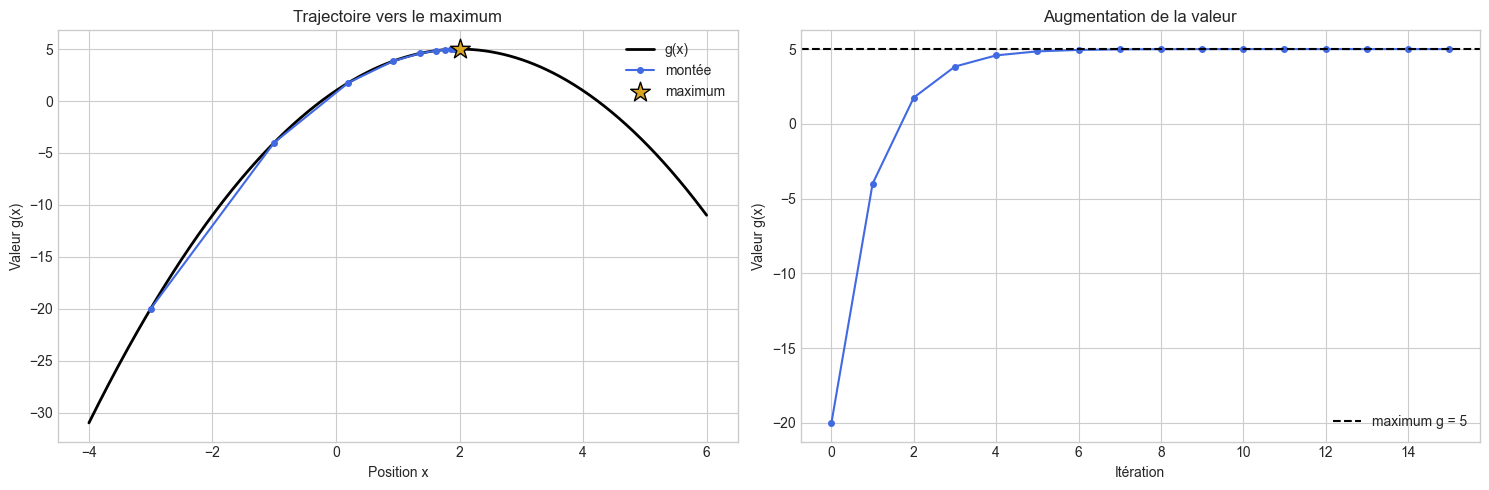

In [5]:
# Grille utilisée pour dessiner la parabole.
x_grille = np.linspace(-4, 6, 500)

# Numéros des itérations.
iterations_1d = np.arange(len(trajectoire_1d))

# Deux vues complémentaires dans une même figure.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# À gauche : positions directement sur la fonction.
axes[0].plot(x_grille, fonction_1d(x_grille), color="black", linewidth=2, label="g(x)")
axes[0].plot(trajectoire_1d, valeurs_1d, "o-", color="royalblue", markersize=4, label="montée")
axes[0].scatter(2, 5, marker="*", s=220, color="goldenrod", edgecolor="black", zorder=6, label="maximum")
axes[0].set_title("Trajectoire vers le maximum")
axes[0].set_xlabel("Position x")
axes[0].set_ylabel("Valeur g(x)")
axes[0].legend()

# À droite : augmentation de la fonction au fil des étapes.
axes[1].plot(iterations_1d, valeurs_1d, "o-", color="royalblue", markersize=4)
axes[1].axhline(5, linestyle="--", color="black", label="maximum g = 5")
axes[1].set_title("Augmentation de la valeur")
axes[1].set_xlabel("Itération")
axes[1].set_ylabel("Valeur g(x)")
axes[1].legend()

plt.tight_layout()
plt.show()

La valeur augmente à chaque étape et se rapproche de $5$. En même temps, le gradient se rapproche de zéro parce que la pente devient horizontale au sommet.

## 8. Deuxième cas : une surface 3D

Nous passons à la fonction concave :

$$g(x,y)=-(x-1)^2-2(y+2)^2+10.$$

Son gradient est :

$$∇g(x,y)=(-2(x-1), -4(y+2)).$$

Son unique maximum global est situé en $(1,-2)$ et vaut $10$.

## 9. Programmer la fonction 2D et son gradient

In [6]:
def fonction_2d(x, y):
    """Calcule la hauteur de la surface concave."""
    # Les deux termes négatifs créent un bol renversé.
    return -(x - 1) ** 2 - 2 * (y + 2) ** 2 + 10


def gradient_2d(x, y):
    """Retourne les deux composantes du gradient."""
    # Pente lorsque x varie et que y reste fixe.
    pente_x = -2 * (x - 1)

    # Pente lorsque y varie et que x reste fixe.
    pente_y = -4 * (y + 2)

    return np.array([pente_x, pente_y])

## 10. Visualiser la surface avant l'optimisation

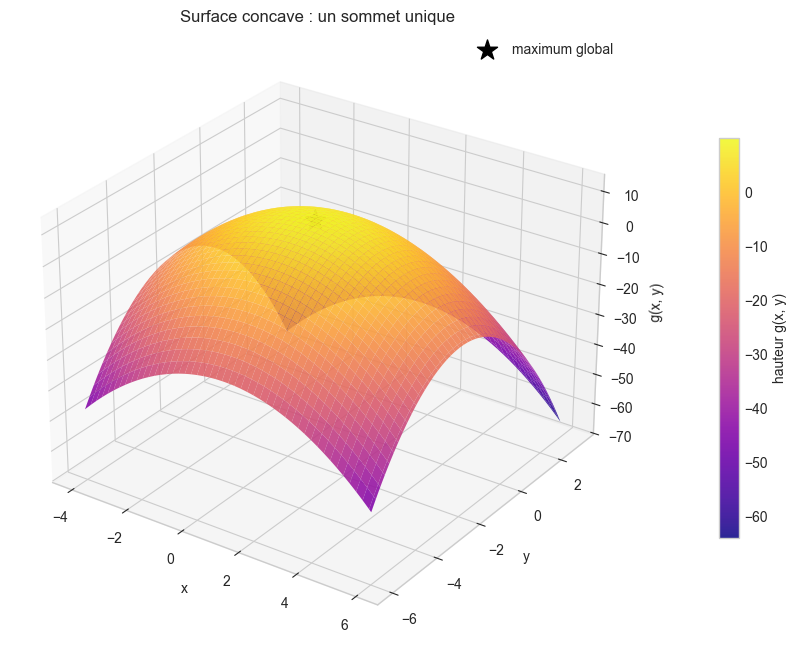

In [8]:
# Valeurs utilisées sur les deux axes du plan.
valeurs_x = np.linspace(-4, 6, 140)
valeurs_y = np.linspace(-6, 3, 140)

# Construction de toutes les combinaisons entre x et y.
X, Y = np.meshgrid(valeurs_x, valeurs_y)

# Hauteur de la surface pour chaque couple.
Z = fonction_2d(X, Y)

# Création de la scène 3D.
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Tracé du bol renversé.
surface = ax.plot_surface(X, Y, Z, cmap="plasma", alpha=0.88, linewidth=0)

# Une étoile indique le sommet global.
ax.scatter(1, -2, 10, marker="*", s=230, color="black", edgecolor="black", depthshade=False, label="maximum global")

ax.set_title("Surface concave : un sommet unique")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("g(x, y)")
ax.view_init(elev=28, azim=-55)
ax.legend(loc="upper right")
fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.1, label="hauteur g(x, y)")
plt.show()

## 11. Calculer une mise à jour vectorielle

Nous partons de $(-3,2)$ avec $α=0.1$. Le gradient est :

$$∇g(-3,2)=(8,-16).$$

La montée met à jour simultanément les deux coordonnées.

In [9]:
# Point initial sur la surface.
point_depart = np.array([-3.0, 2.0])

# Taux choisi pour les deux composantes.
taux_2d = 0.1

# Calcul du gradient au point initial.
gradient_depart = gradient_2d(point_depart[0], point_depart[1])

# En montée, le déplacement possède le même signe que le gradient.
deplacement = taux_2d * gradient_depart

# Addition vectorielle donnant la nouvelle position.
point_nouveau = point_depart + deplacement

print("Point initial   :", point_depart)
print("Gradient        :", gradient_depart)
print("Déplacement     :", deplacement)
print("Nouveau point   :", point_nouveau)
print(f"Valeur avant   : {fonction_2d(*point_depart):.2f}")
print(f"Valeur après   : {fonction_2d(*point_nouveau):.2f}")

Point initial   : [-3.  2.]
Gradient        : [  8. -16.]
Déplacement     : [ 0.8 -1.6]
Nouveau point   : [-2.2  0.4]
Valeur avant   : -38.00
Valeur après   : -11.76


La première mise à jour est :

$$(-3,2)+0.1(8,-16)=(-2,0.4).$$

La hauteur augmente de $-38$ à $-10.52$.

## 12. Programmer la montée en deux dimensions

In [10]:
def montee_gradient_2d(gradient_g, point_depart, taux, nombre_iterations):
    """Retourne toutes les positions [x, y] visitées pendant la montée."""

    # Conversion du point initial en tableau décimal.
    point = np.array(point_depart, dtype=float)

    # Une copie du point ouvre l'historique.
    historique = [point.copy()]

    for _ in range(nombre_iterations):
        # Direction de montée calculée à la position actuelle.
        vecteur_gradient = gradient_g(point[0], point[1])

        # Le signe plus fait avancer dans le sens du gradient.
        point = point + taux * vecteur_gradient

        # Conservation d'une copie de la nouvelle position.
        historique.append(point.copy())

    return np.array(historique)


# Trente étapes depuis (-3, 2).
trajectoire_2d = montee_gradient_2d(gradient_2d, (-3, 2), taux=0.1, nombre_iterations=30)

# Séparation des deux coordonnées.
trajet_x = trajectoire_2d[:, 0]
trajet_y = trajectoire_2d[:, 1]

# Hauteur associée à chaque position.
trajet_z = fonction_2d(trajet_x, trajet_y)

print("Position finale :", np.round(trajectoire_2d[-1], 6))
print(f"Valeur finale   : {trajet_z[-1]:.8f}")

Position finale : [ 0.995048 -1.999999]
Valeur finale   : 9.99997548


## 13. Visualiser la trajectoire sur la surface 3D

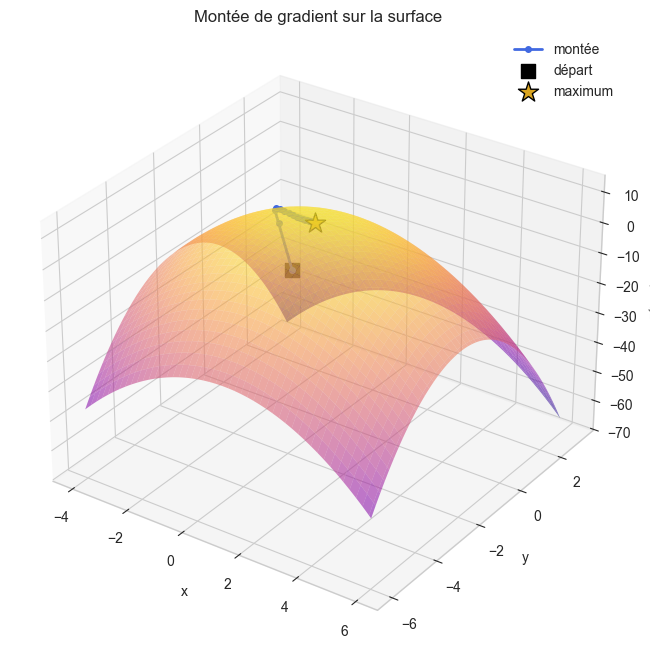

In [11]:
# Nouvelle scène 3D.
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Surface rendue transparente pour montrer le chemin.
ax.plot_surface(X, Y, Z, cmap="plasma", alpha=0.55, linewidth=0)

# Trajectoire ascendante sur la surface.
ax.plot(trajet_x, trajet_y, trajet_z, "o-", color="royalblue", markersize=4, linewidth=2, label="montée")

# Départ et maximum.
ax.scatter(trajet_x[0], trajet_y[0], trajet_z[0], marker="s", s=90, color="black", label="départ")
ax.scatter(1, -2, 10, marker="*", s=230, color="goldenrod", edgecolor="black", depthshade=False, label="maximum")

ax.set_title("Montée de gradient sur la surface")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("g(x, y)")
ax.view_init(elev=30, azim=-55)
ax.legend()
plt.show()

## 14. Visualiser la trajectoire sur les courbes de niveau

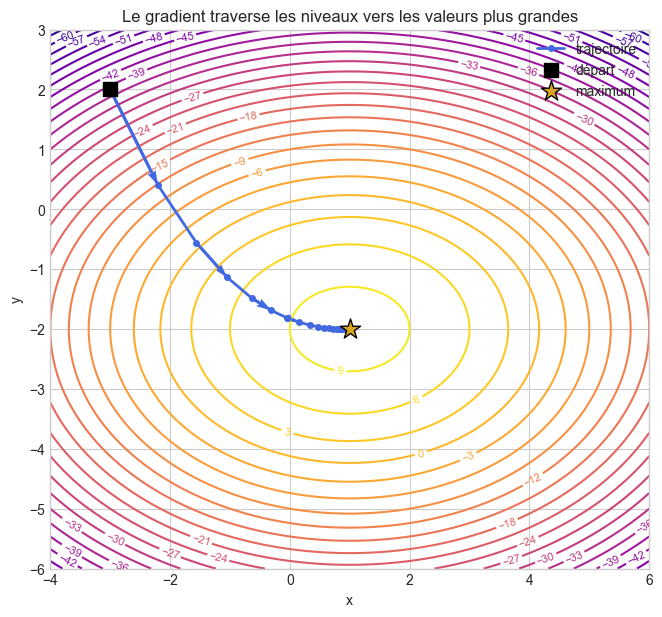

In [12]:
# Vue de dessus de la même surface.
fig, ax = plt.subplots(figsize=(10, 7))
niveaux = ax.contour(X, Y, Z, levels=24, cmap="plasma")
ax.clabel(niveaux, inline=True, fontsize=8)

# Chemin dans le plan des paramètres.
ax.plot(trajet_x, trajet_y, "o-", color="royalblue", markersize=4, linewidth=2, label="trajectoire")

# Quelques flèches indiquent le sens de la montée.
for index in range(0, min(12, len(trajectoire_2d) - 1), 2):
    delta = trajectoire_2d[index + 1] - trajectoire_2d[index]
    ax.quiver(
        trajectoire_2d[index, 0], trajectoire_2d[index, 1],
        delta[0], delta[1],
        angles="xy", scale_units="xy", scale=1, color="royalblue", width=0.005,
    )

# Marquage des deux extrémités.
ax.scatter(trajet_x[0], trajet_y[0], marker="s", s=100, color="black", zorder=6, label="départ")
ax.scatter(1, -2, marker="*", s=230, color="goldenrod", edgecolor="black", zorder=7, label="maximum")

ax.set_title("Le gradient traverse les niveaux vers les valeurs plus grandes")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right")
plt.show()

## 15. Observer la convergence des coordonnées et de la hauteur

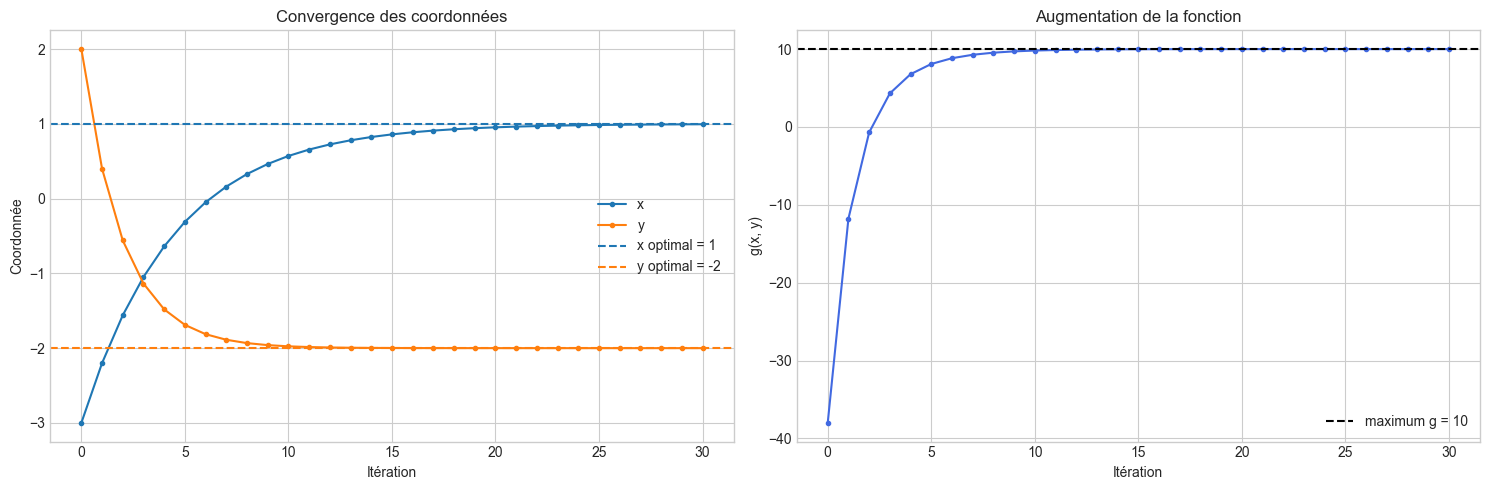

In [13]:
# Numéros des étapes, y compris le départ.
iterations_2d = np.arange(len(trajectoire_2d))

# Deux graphiques côte à côte.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Évolution de x et y vers leurs valeurs optimales.
axes[0].plot(iterations_2d, trajet_x, "o-", markersize=3, label="x")
axes[0].plot(iterations_2d, trajet_y, "o-", markersize=3, label="y")
axes[0].axhline(1, linestyle="--", color="tab:blue", label="x optimal = 1")
axes[0].axhline(-2, linestyle="--", color="tab:orange", label="y optimal = -2")
axes[0].set_title("Convergence des coordonnées")
axes[0].set_xlabel("Itération")
axes[0].set_ylabel("Coordonnée")
axes[0].legend()

# Augmentation de la hauteur jusqu'au maximum 10.
axes[1].plot(iterations_2d, trajet_z, "o-", color="royalblue", markersize=3)
axes[1].axhline(10, linestyle="--", color="black", label="maximum g = 10")
axes[1].set_title("Augmentation de la fonction")
axes[1].set_xlabel("Itération")
axes[1].set_ylabel("g(x, y)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 16. Maximiser $g$ ou minimiser $-g$

Définissons $f(x,y)=-g(x,y)$. Son gradient vérifie :

$$∇f(x,y)=-∇g(x,y).$$

La descente appliquée à $f$ devient alors exactement la montée appliquée à $g$.

In [14]:
def gradient_fonction_negative(x, y):
    """Gradient de f = -g."""
    return -gradient_2d(x, y)


def descente_gradient_2d(gradient_f, point_depart, taux, nombre_iterations):
    """Descente utilisée pour vérifier l'équivalence."""
    point = np.array(point_depart, dtype=float)
    historique = [point.copy()]

    for _ in range(nombre_iterations):
        # Ici, le signe moins est celui de la descente.
        point = point - taux * gradient_f(point[0], point[1])
        historique.append(point.copy())

    return np.array(historique)


# Descente sur -g utilisant exactement les mêmes paramètres.
trajectoire_negative = descente_gradient_2d(
    gradient_fonction_negative, (-3, 2), taux=0.1, nombre_iterations=30
)

# allclose vérifie numériquement que toutes les positions sont identiques.
trajectoires_identiques = np.allclose(trajectoire_2d, trajectoire_negative)
print("Trajectoires identiques :", trajectoires_identiques)

Trajectoires identiques : True


## 17. Lien avec le machine learning

En machine learning, nous rencontrons les deux formulations :

- minimiser une erreur ou une fonction de coût avec la descente ;
- maximiser une vraisemblance, une log-vraisemblance ou une récompense avec la montée.

Dans la pratique, de nombreux logiciels transforment une maximisation en minimisation en changeant simplement le signe de la fonction objectif.

## 18. Ce qu'il faut retenir

1. Le gradient pointe naturellement vers la montée.
2. La montée ajoute $α∇g$ à la position actuelle.
3. La descente soustrait $α∇f$.
4. Au voisinage d'un maximum, la pente et les déplacements deviennent progressivement nuls.
5. Maximiser $g$ équivaut exactement à minimiser $-g$.
6. Le choix du taux d'apprentissage reste aussi important en montée qu'en descente.

## 19. Exercice

Considère la fonction :

$$h(x,y)=-2(x+1)^2-(y-3)^2+7.$$

1. Trouve son maximum global sans Python.
2. Calcule les deux composantes de son gradient.
3. Pars du point $(2,-1)$ avec $α=0.1$.
4. Calcule manuellement la première mise à jour.
5. Programme vingt étapes de montée.
6. Représente la trajectoire sur la surface et sur les courbes de niveau.

### Bonus

Définis $q=-h$ et vérifie que la descente sur $q$ produit exactement les mêmes positions.